In [1]:
from magie import download_magie
from magie.file_conversions import magie2iaga2002
import numpy as np

In [2]:
file_name = download_magie(np.datetime64('2024-05-07T00:00:00'), np.datetime64('2024-05-17T00:00'), ['dun'])

  0%|          | 0/11 [00:00<?, ?it/s]

Downloading: 100.00% [3211264/3203958 bytes]
Download complete!


  9%|▉         | 1/11 [00:04<00:42,  4.21s/it]

Downloading: 100.00% [4472832/4470303 bytes]
Download complete!


 18%|█▊        | 2/11 [00:09<00:42,  4.70s/it]

...

 82%|████████▏ | 9/11 [00:42<00:09,  4.84s/it]

Downloading: 100.00% [4489216/4481423 bytes]
Download complete!


 91%|█████████ | 10/11 [00:47<00:04,  4.94s/it]

Downloading: 100.00% [4489216/4481620 bytes]
Download complete!


100%|██████████| 11/11 [00:52<00:00,  4.81s/it]


In [3]:
from magie import download_magie
from magie.file_conversions import magie2iaga2002
import numpy as np

In [35]:
import pandas as pd
df= pd.read_hdf('./dun2024_05_07_to_2024_05_17.hdf5')
df["Date_UTC"] = pd.to_datetime(df["Date_UTC"]).dt.tz_localize(None)
df= pd.concat([pd.DataFrame(columns=df.columns, data=[[pd.Timestamp(df.Date_UTC.min().to_numpy().astype('datetime64[D]').astype('datetime64[ns]')), 'dun'] + [np.nan] * (len(df.columns) - 2)]), df])

In [6]:
new_df= magie2iaga2002(df, 'dun')

In [7]:
df.Date_UTC.min(), df.Date_UTC.max()

(Timestamp('2024-05-07 00:00:00'), Timestamp('2024-05-17 00:00:00'))

In [8]:
with open(new_df[1], 'w') as file:
    file.write(new_df[0])


In [9]:
from magpy.stream import read
data = read(new_df[1])

In [10]:
data2= data.filter()

In [11]:
from magie.utils import get_site_metadata
from magpy.core import activity as act
met= get_site_metadata('dun')
kvals = act.K_fmi(data2, K9_limit=met['k9_threshold'], longitude=met['geodetic_longitude'], step_size=60)

In [18]:
kvals['var1']

array([ 1.,  2.,  2.,  1.,  2.,  2.,  1.,  1.,  1.,  2.,  1.,  2.,  1.,
        1.,  3.,  2.,  3.,  2.,  2.,  3.,  5.,  8.,  7.,  9.,  9.,  9.,
        7.,  9.,  8.,  7.,  7.,  7.,  5.,  6.,  3.,  4.,  2., -1., -1.,
       -1., -1., -1., -1.,  2.,  4.,  3.,  3.,  2.,  1.,  1.,  2.,  2.,
        3.,  2.,  2.,  0.,  1.,  2.,  3.,  3.,  2.,  3.,  3.,  3.])

In [27]:
kvals['time']

array([datetime.datetime(2024, 5, 8, 1, 30),
       datetime.datetime(2024, 5, 8, 4, 30),
       datetime.datetime(2024, 5, 8, 7, 30),
       datetime.datetime(2024, 5, 8, 10, 30),
       datetime.datetime(2024, 5, 8, 13, 30),
       datetime.datetime(2024, 5, 8, 16, 30),
       datetime.datetime(2024, 5, 8, 19, 30),
       datetime.datetime(2024, 5, 8, 22, 30),
       datetime.datetime(2024, 5, 9, 1, 30),
       datetime.datetime(2024, 5, 9, 4, 30),
       datetime.datetime(2024, 5, 9, 7, 30),
       datetime.datetime(2024, 5, 9, 10, 30),
       datetime.datetime(2024, 5, 9, 13, 30),
       datetime.datetime(2024, 5, 9, 16, 30),
       datetime.datetime(2024, 5, 9, 19, 30),
       datetime.datetime(2024, 5, 9, 22, 30),
       datetime.datetime(2024, 5, 10, 1, 30),
       datetime.datetime(2024, 5, 10, 4, 30),
       datetime.datetime(2024, 5, 10, 7, 30),
       datetime.datetime(2024, 5, 10, 10, 30),
       datetime.datetime(2024, 5, 10, 13, 30),
       datetime.datetime(2024, 5, 10, 

In [19]:
from magie import plot_k

(<Figure size 3000x1500 with 2 Axes>, <AxesSubplot:>, <AxesSubplot:>)

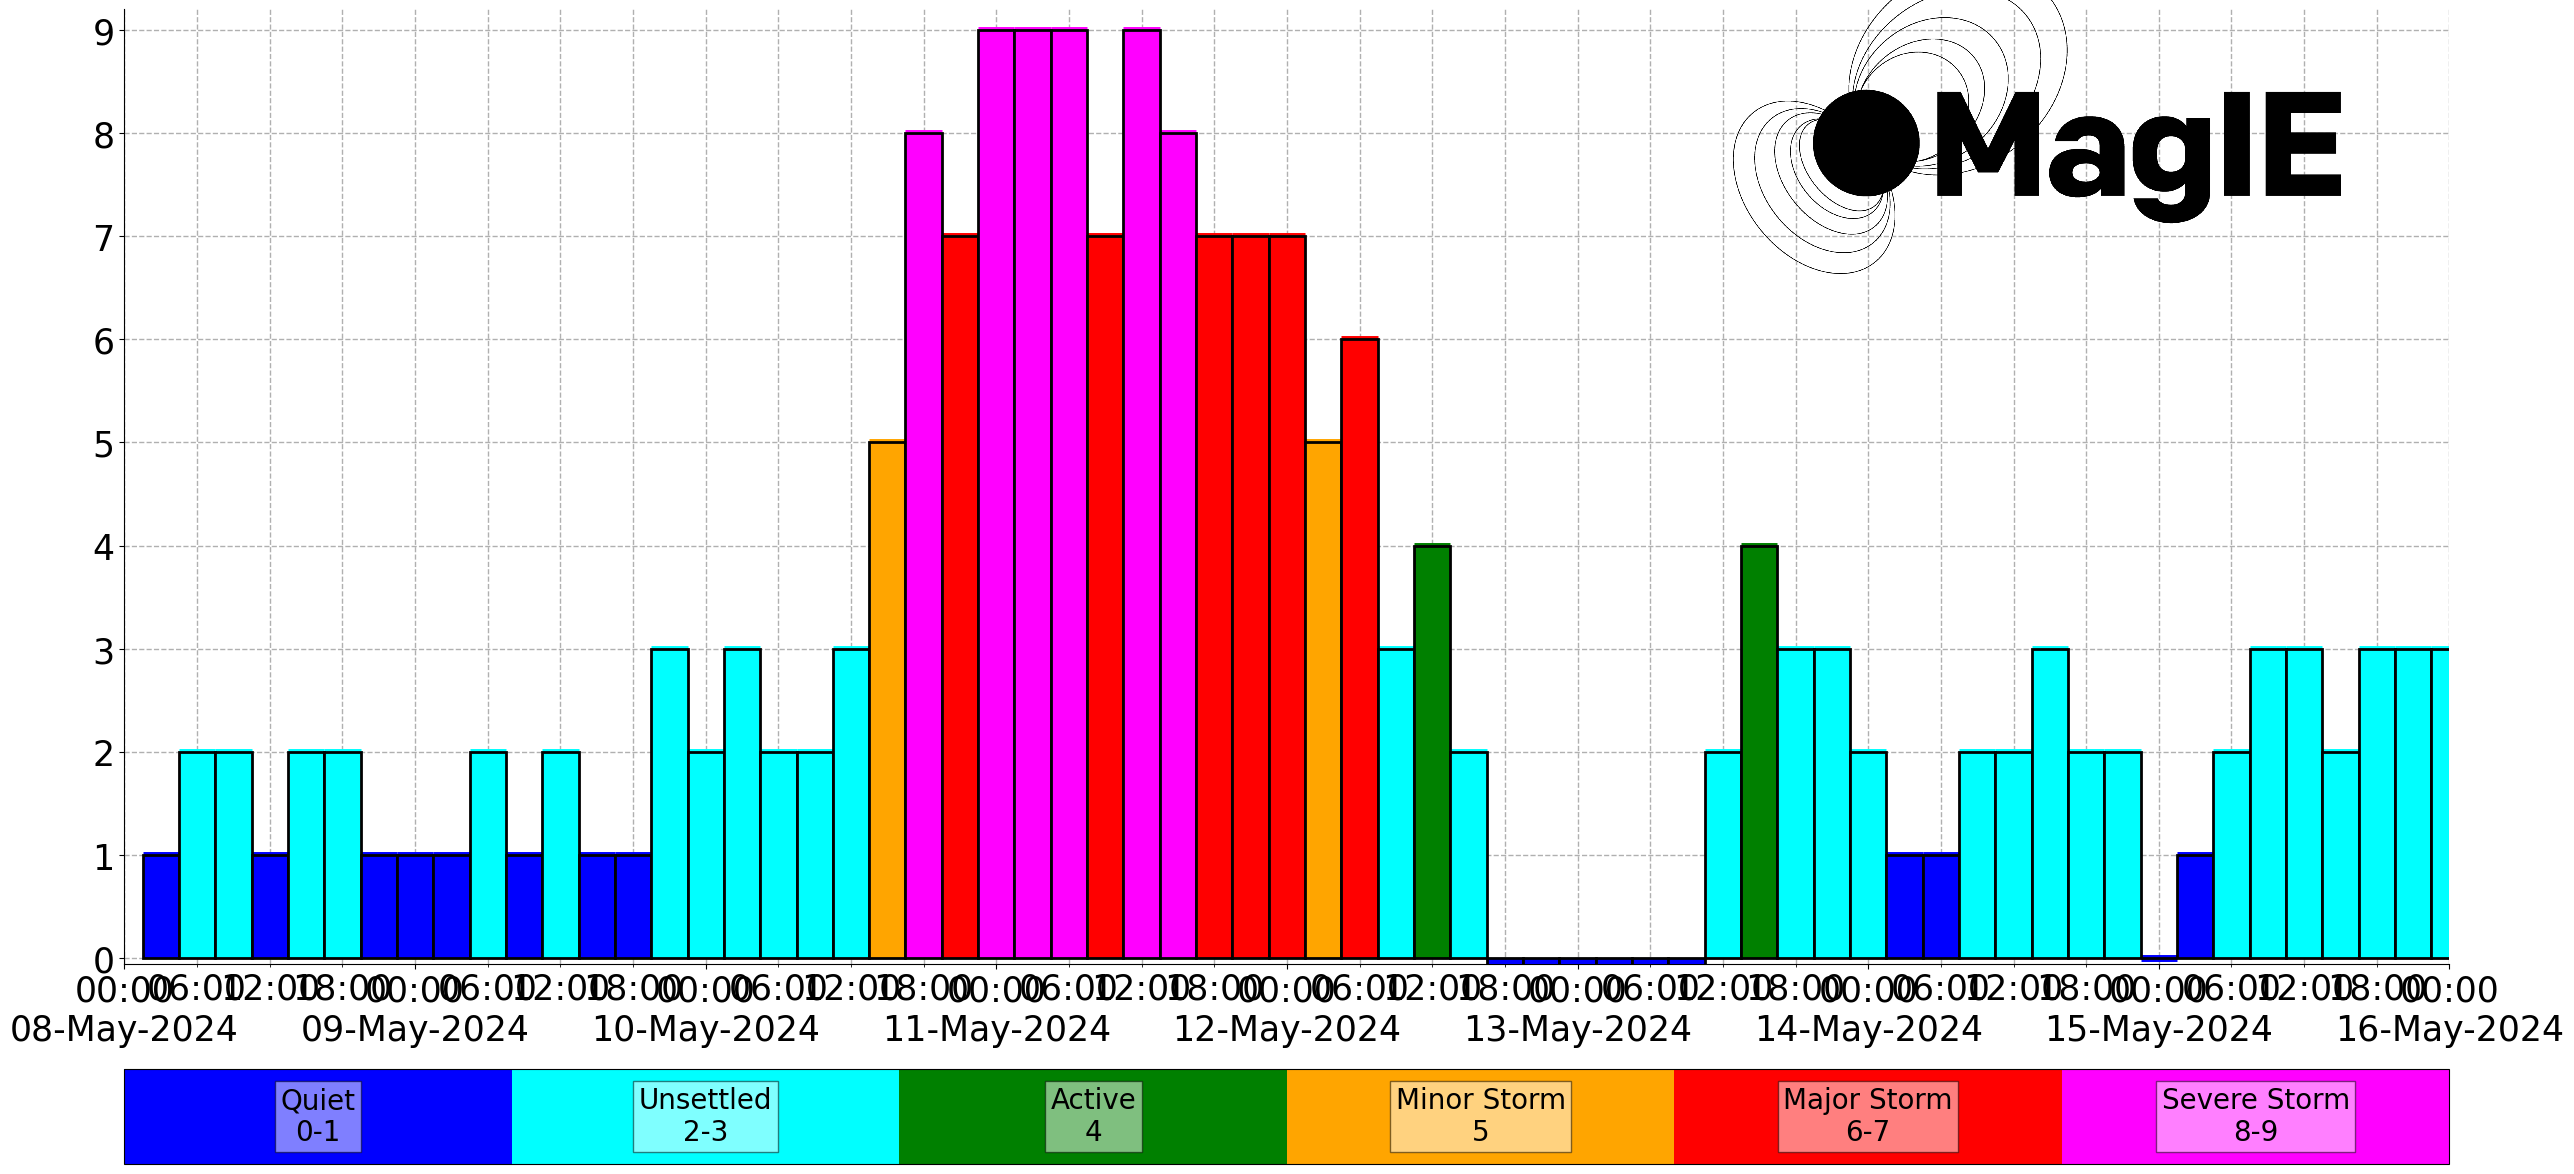

In [31]:
plot_k(pd.DataFrame({'K_index': kvals['var1']}, index= kvals['time']))

In [34]:
data2['time']

array([datetime.datetime(2024, 5, 7, 0, 0),
       datetime.datetime(2024, 5, 7, 0, 1),
       datetime.datetime(2024, 5, 7, 0, 2), ...,
       datetime.datetime(2024, 5, 16, 23, 57),
       datetime.datetime(2024, 5, 16, 23, 58),
       datetime.datetime(2024, 5, 16, 23, 59)], dtype=object)